<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/GenericT_Hecktor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(726, 17)
(423, 12)
train sample: HPV Status
1.0    320
0.0     18
Name: count, dtype: int64 

test sample: HPV Status
1.0    80
0.0     5
Name: count, dtype: int64


/tmp/ipykernel_1258/1330002332.py:54: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['T-stage']=df['T-stage'].replace({'T0':0,'T1':1,'T2':2,'T3':3,'T4':4})
/tmp/ipykernel_1258/1330002332.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['N-stage']=df['N-stage'].replace({'N0':0,'N1':1,'N2':2,'N3':3})
/tmp/ipykernel_1258/1330002332.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To op

Epoch 50, Train=0.4704, Test=0.4248 Best Epoch=46
Epoch 100, Train=0.3716, Test=0.3915 Best Epoch=81
Epoch 150, Train=0.2550, Test=0.3356 Best Epoch=133
Epoch 200, Train=0.2184, Test=0.4240 Best Epoch=133
Epoch 250, Train=0.2924, Test=0.5469 Best Epoch=133
Epoch 300, Train=0.2477, Test=0.5516 Best Epoch=133
Epoch 350, Train=0.1720, Test=0.6589 Best Epoch=133
Epoch 400, Train=0.1859, Test=0.8923 Best Epoch=133
Epoch 450, Train=0.1598, Test=0.6264 Best Epoch=410
Epoch 500, Train=0.2983, Test=0.7095 Best Epoch=410
Best Test Loss = 0.26541760563850403
Best Epoch = 410
results:               precision    recall  f1-score   support

           0     0.2778    1.0000    0.4348         5
           1     1.0000    0.8375    0.9116        80

    accuracy                         0.8471        85
   macro avg     0.6389    0.9187    0.6732        85
weighted avg     0.9575    0.8471    0.8835        85

Balanced Accuracy: 0.9187
F1-score:          0.9116
AUC:               0.9125


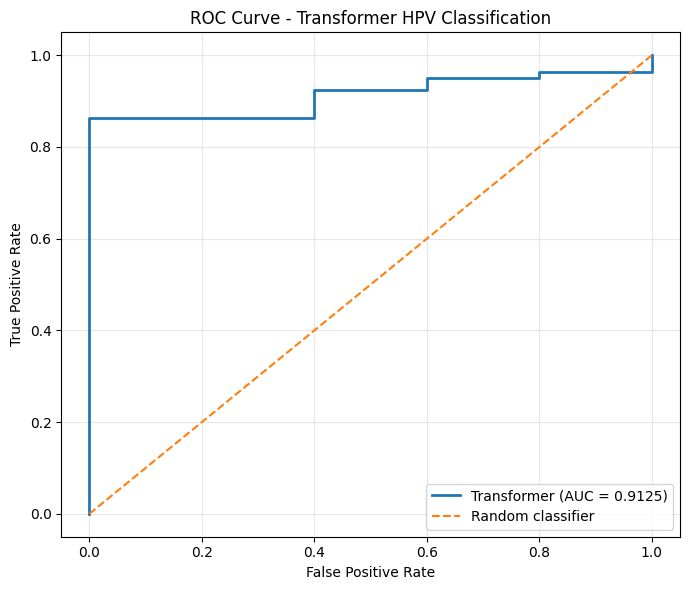

AUC: 0.9125


In [3]:
# ============================================================
# Transformer42_Hecktor - NO SMOTE
# ============================================================

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import os,pandas as pd,numpy as np,random,torch,torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,balanced_accuracy_score,f1_score,roc_auc_score,confusion_matrix

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
def seed_everything(seed=42):
    torch.manual_seed(seed);torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED']=str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"
    torch.use_deterministic_algorithms(True,warn_only=True)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
    torch.backends.cuda.matmul.allow_tf32=False
    torch.backends.cudnn.allow_tf32=False
    np.random.seed(seed);random.seed(seed)

SEED=42
seed_everything(seed=SEED)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------
sheet_id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv"
url=f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"
df=pd.read_csv(url)
print(df.shape)
df.head()

# ------------------------------------------------------------
# Data Cleaning
# ------------------------------------------------------------
df=df.dropna(subset=['HPV Status'])
tobacco_mode=df['Tobacco Consumption'].mode()[0]
df['Tobacco Consumption']=df['Tobacco Consumption'].fillna(tobacco_mode)
alcohol_mode=df['Alcohol Consumption'].mode()[0]
df['Alcohol Consumption']=df['Alcohol Consumption'].fillna(alcohol_mode)
df=df.drop(columns=['PatientID','CenterID','Task 1','Task 2','Task 3'])
df=df.dropna()
print(df.shape)

# ------------------------------------------------------------
# Stage Conversion
# ------------------------------------------------------------
df['T-stage']=df['T-stage'].replace({'T0':0,'T1':1,'T2':2,'T3':3,'T4':4})
df['N-stage']=df['N-stage'].replace({'N0':0,'N1':1,'N2':2,'N3':3})
df['M-stage']=df['M-stage'].replace({'M0':0,'M1':1})

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------
X=df[['Age','Gender','Tobacco Consumption','Alcohol Consumption','Performance Status','Relapse','RFS','Treatment','T-stage','N-stage','M-stage']]
y=df['HPV Status']

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=SEED)
print('train sample:',y_train.value_counts(),'\n')
print('test sample:',y_test.value_counts())

# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# ------------------------------------------------------------
# Torch Conversion - No SMOTE
# ------------------------------------------------------------
X_train=torch.FloatTensor(X_train)
y_train=torch.LongTensor(y_train.to_numpy())
X_test=torch.FloatTensor(X_test)
y_test=torch.LongTensor(y_test.to_numpy())

# ------------------------------------------------------------
# Model Architecture
# Transformer-based model for tabular classification
# ------------------------------------------------------------
class HPVNet_Transformer(nn.Module):
    def __init__(self,num_features=11,d_model=32,nhead=4,num_layers=2,dim_feedforward=64,dropout=0.1,num_classes=2):
        super().__init__()
        self.num_features=num_features
        self.d_model=d_model
        self.feature_projection=nn.Linear(1,d_model)
        self.feature_embedding=nn.Parameter(torch.zeros(1,num_features,d_model))
        self.cls_token=nn.Parameter(torch.zeros(1,1,d_model))
        encoder_layer=nn.TransformerEncoderLayer(d_model=d_model,nhead=nhead,dim_feedforward=dim_feedforward,dropout=dropout,activation="gelu",batch_first=True,norm_first=True)
        self.transformer=nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.norm=nn.LayerNorm(d_model)
        self.classifier=nn.Sequential(nn.Linear(d_model,16),nn.ReLU(),nn.Dropout(dropout),nn.Linear(16,num_classes))
        self._init_weights()
    def _init_weights(self):
        nn.init.normal_(self.feature_embedding,mean=0.0,std=0.02)
        nn.init.normal_(self.cls_token,mean=0.0,std=0.02)
        nn.init.xavier_uniform_(self.feature_projection.weight)
        nn.init.zeros_(self.feature_projection.bias)
    def forward(self,x):
        batch_size=x.size(0)
        x=x.unsqueeze(-1)
        x=self.feature_projection(x)
        x=x+self.feature_embedding
        cls_tokens=self.cls_token.expand(batch_size,-1,-1)
        x=torch.cat([cls_tokens,x],dim=1)
        x=self.transformer(x)
        x=self.norm(x[:,0])
        logits=self.classifier(x)
        return logits

# ------------------------------------------------------------
# Model, Class Weights and Optimiser
# ------------------------------------------------------------
# ------------------------------------------------------------
# Model, Class Weights and Optimiser
# ------------------------------------------------------------
model=HPVNet_Transformer()
class_counts=np.bincount(y_train.numpy())
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weights=torch.tensor(class_weights,dtype=torch.float32)
criterion=nn.CrossEntropyLoss(weight=class_weights)
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

# optimizer=torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.01)

if os.path.exists("best_model_transformer.pth"):
    os.remove("best_model_transformer.pth")

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------
epochs=500
best_val_loss=float('inf')
best_epoch=0

for epoch in range(epochs):
    model.train()
    outputs=model(X_train)
    train_loss=criterion(outputs,y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        test_outputs=model(X_test)
        test_loss=criterion(test_outputs,y_test)
    if test_loss.item()<best_val_loss:
        best_val_loss=test_loss.item()
        best_epoch=epoch+1
        torch.save(model.state_dict(),"best_model_transformer.pth")
    if (epoch+1)%50==0:
        print(f"Epoch {epoch+1}, Train={train_loss.item():.4f}, Test={test_loss.item():.4f}",f"Best Epoch={best_epoch}")

print("Best Test Loss =",best_val_loss)
print("Best Epoch =",best_epoch)

# ------------------------------------------------------------
# Inference
# ------------------------------------------------------------
model.load_state_dict(torch.load("best_model_transformer.pth"))
model.eval()

with torch.no_grad():
    outputs=model(X_test)
    probabilities=torch.softmax(outputs,dim=1)
    predicted=torch.argmax(outputs,dim=1)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------
results=classification_report(y_test.numpy(),predicted.numpy(),digits=4)
print('results:',results)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
bal_acc=balanced_accuracy_score(y_test.numpy(),predicted.numpy())
f1=f1_score(y_test.numpy(),predicted.numpy())
y_prob=probabilities.cpu().numpy()

if y_prob.shape[1]==2:
    auc=roc_auc_score(y_test.numpy(),y_prob[:,1])
else:
    auc=roc_auc_score(y_test.numpy(),y_prob,multi_class="ovr",average="weighted")

print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"F1-score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")

# ------------------------------------------------------------
# ROC / AUC Curve
# ------------------------------------------------------------
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_score=y_prob[:,1]
fpr,tpr,thresholds=roc_curve(y_test.numpy(),y_score)
auc=roc_auc_score(y_test.numpy(),y_score)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,linewidth=2,label=f'Transformer (AUC = {auc:.4f})')
plt.plot([0,1],[0,1],linestyle='--',linewidth=1.5,label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Transformer HPV Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")